Step 02: Data Collection

In [3]:
import pandas as pd
import numpy as np

# Load the datasets from the sample_data directory
train_df = pd.read_csv('sample_data/mnist_train.csv')
test_df = pd.read_csv('sample_data/mnist_test.csv')

# Display dataset dimensions
print(f"Training set dimensions: {train_df.shape}")
print(f"Testing set dimensions: {test_df.shape}")

# Display first few entries of the training set
print("\nFirst 5 rows of the training set:")
print(train_df.head())

Training set dimensions: (60000, 785)
Testing set dimensions: (10000, 785)

First 5 rows of the training set:
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


Step 03: Exploratory Data Analysis (EDA)

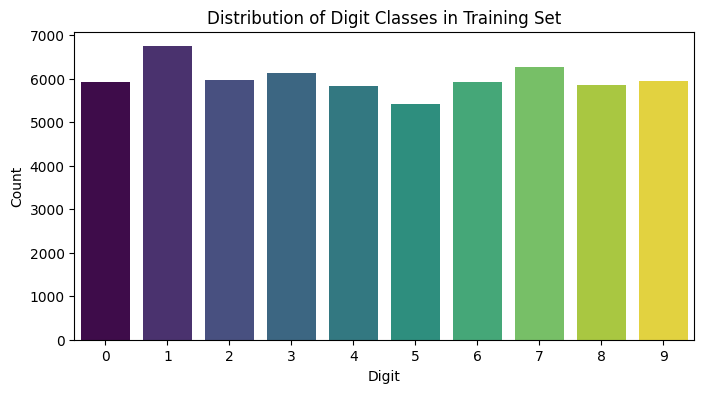

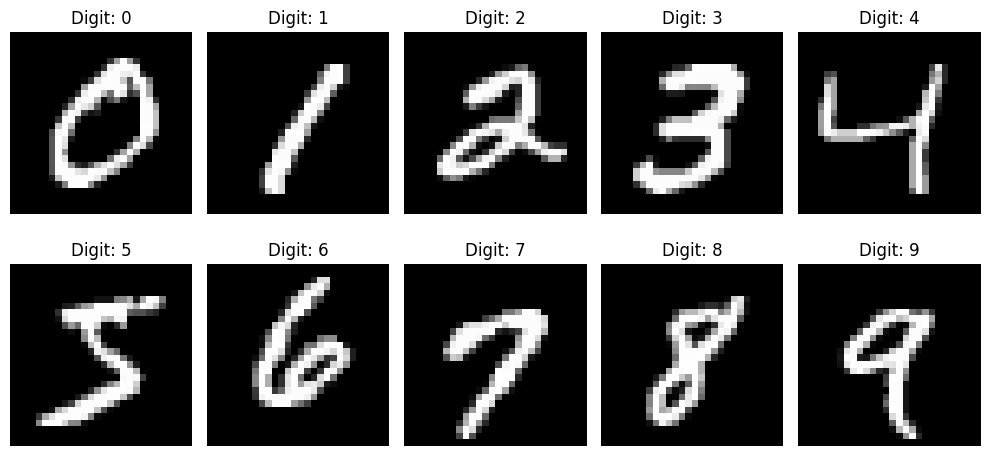

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Class Distribution Analysis (Checking the frequency of each digit from 0 to 9)
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=train_df, hue='label', palette='viridis', legend=False)
plt.title("Distribution of Digit Classes in Training Set")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

# 2. Visualizing a grid of samples for digits 0 through 9
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    digit_row = train_df[train_df['label'] == i].iloc[0]
    pixels = digit_row.iloc[1:].values.reshape(28, 28)

    ax.imshow(pixels, cmap='gray')
    ax.title.set_text(f"Digit: {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Step 04: Data Preprocessing / Cleaning

In [6]:
import pandas as pd
import numpy as np

# 1. Separating features (pixels) and labels (target)
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# 2. Checking for missing values
print(f"Missing values in training data: {np.isnan(X_train).sum()}")
print(f"Missing values in testing data: {np.isnan(X_test).sum()}")

# 3. Normalization (Scaling pixel values from [0, 255] to [0.0, 1.0])
X_train = X_train / 255.0
X_test = X_test / 255.0

# 4. Reshaping for Convolutional Neural Network (CNN) if needed, or keeping flattened for ANN
# For CNN: (Samples, Height, Width, Channels) -> (60000, 28, 28, 1)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print(f"Preprocessed Training Data Shape: {X_train_cnn.shape}")
print(f"Preprocessed Testing Data Shape: {X_test_cnn.shape}")

Missing values in training data: 0
Missing values in testing data: 0
Preprocessed Training Data Shape: (60000, 28, 28, 1)
Preprocessed Testing Data Shape: (10000, 28, 28, 1)


Step 05: Feature Selection & Engineering

In [1]:
# For the MNIST dataset, raw pixels serve as our features.
# The Convolutional Neural Network (CNN) automatically extracts 
# features (such as edges, lines, and curves) directly from the images.
# Therefore, we are not performing any manual feature engineering here, 
# but rather keeping the preprocessed pixel arrays ready directly for the model.

print("Total Features per Image: 28 x 28 = 784 pixels")
print("Feature Engineering status: Handled automatically by CNN architecture.")

Total Features per Image: 28 x 28 = 784 pixels
Feature Engineering status: Handled automatically by CNN architecture.


Step 06: Split the Dataset

In [ ]:
from sklearn.model_selection import train_test_split

# Split the training data into training (80%) and validation (20%) sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train_split.shape}")
print(f"Validation set shape: {X_val_split.shape}")
print(f"Testing set shape: {X_test_cnn.shape}")

Training set shape: (48000, 28, 28, 1)
Validation set shape: (12000, 28, 28, 1)
Testing set shape: (10000, 28, 28, 1)


Step 07: Model Selection

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define the model architecture (CNN)
model = Sequential([
    # First Convolutional Block
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flattening to connect with Dense layers
    Flatten(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    Dropout(0.5), # To prevent overfitting

    # Output Layer (There are 10 classes from 0 to 9, so softmax is used)
    Dense(10, activation='softmax')
])

# View the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Step 08: Model Training

In [ ]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model (Fitting)
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=5,
    batch_size=64
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9051 - loss: 0.3079 - val_accuracy: 0.9773 - val_loss: 0.0734
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9684 - loss: 0.1043 - val_accuracy: 0.9814 - val_loss: 0.0585
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9778 - loss: 0.0753 - val_accuracy: 0.9889 - val_loss: 0.0394
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9824 - loss: 0.0596 - val_accuracy: 0.9874 - val_loss: 0.0439
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9847 - loss: 0.0527 - val_accuracy: 0.9890 - val_loss: 0.0380


Step 09: Model Evaluation

In [11]:
# Model evaluation on the test dataset
test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9900 - loss: 0.0311

Final Test Loss: 0.0311
Final Test Accuracy: 99.00%


Step 10: Hyperparameter Tuning

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callback to dynamically adjust the learning rate
lr_reduction = ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=2,
    verbose=1,
    factor=0.5,
    min_lr=0.00001
)

# Run fine-tuning epochs to further improve the model (optional)
history_tuned = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=3,
    batch_size=64,
    callbacks=[lr_reduction]
)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9867 - loss: 0.0446 - val_accuracy: 0.9889 - val_loss: 0.0372 - learning_rate: 0.0010
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9889 - loss: 0.0368 - val_accuracy: 0.9898 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9890 - loss: 0.0352 - val_accuracy: 0.9913 - val_loss: 0.0309 - learning_rate: 0.0010


Step 11: Model Testing / Validation (Model Saving & Production Ready)

In [ ]:
# 1. Save the trained model to a file (.h5 format)
model.save('mnist_digit_model.h5')
print("Model successfully saved as 'mnist_digit_model.h5'!")

# 2. Final check on the testing dataset
final_loss, final_acc = model.evaluate(X_test_cnn, y_test)
print(f"Production Readiness - Test Accuracy: {final_acc * 100:.2f}%")

Model successfully saved as 'mnist_digit_model.h5'!
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9919 - loss: 0.0261
Production Readiness - Test Accuracy: 99.19%


Final Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


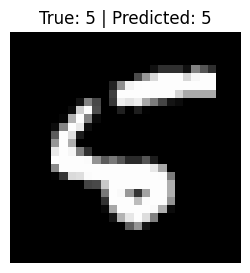

True Label: 5
Predicted Digit: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a random index from the test dataset
index = 8
sample_image = X_test_cnn[index]
true_label = y_test[index]

# Generate prediction using the trained model
prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_digit = np.argmax(prediction)

# Visualize the test image along with the true and predicted labels
plt.figure(figsize=(3, 3))
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"True: {true_label} | Predicted: {predicted_digit}")
plt.axis('off')
plt.show()

print(f"True Label: {true_label}")
print(f"Predicted Digit: {predicted_digit}")